# 1.1.9 Example: Harvest Quotas

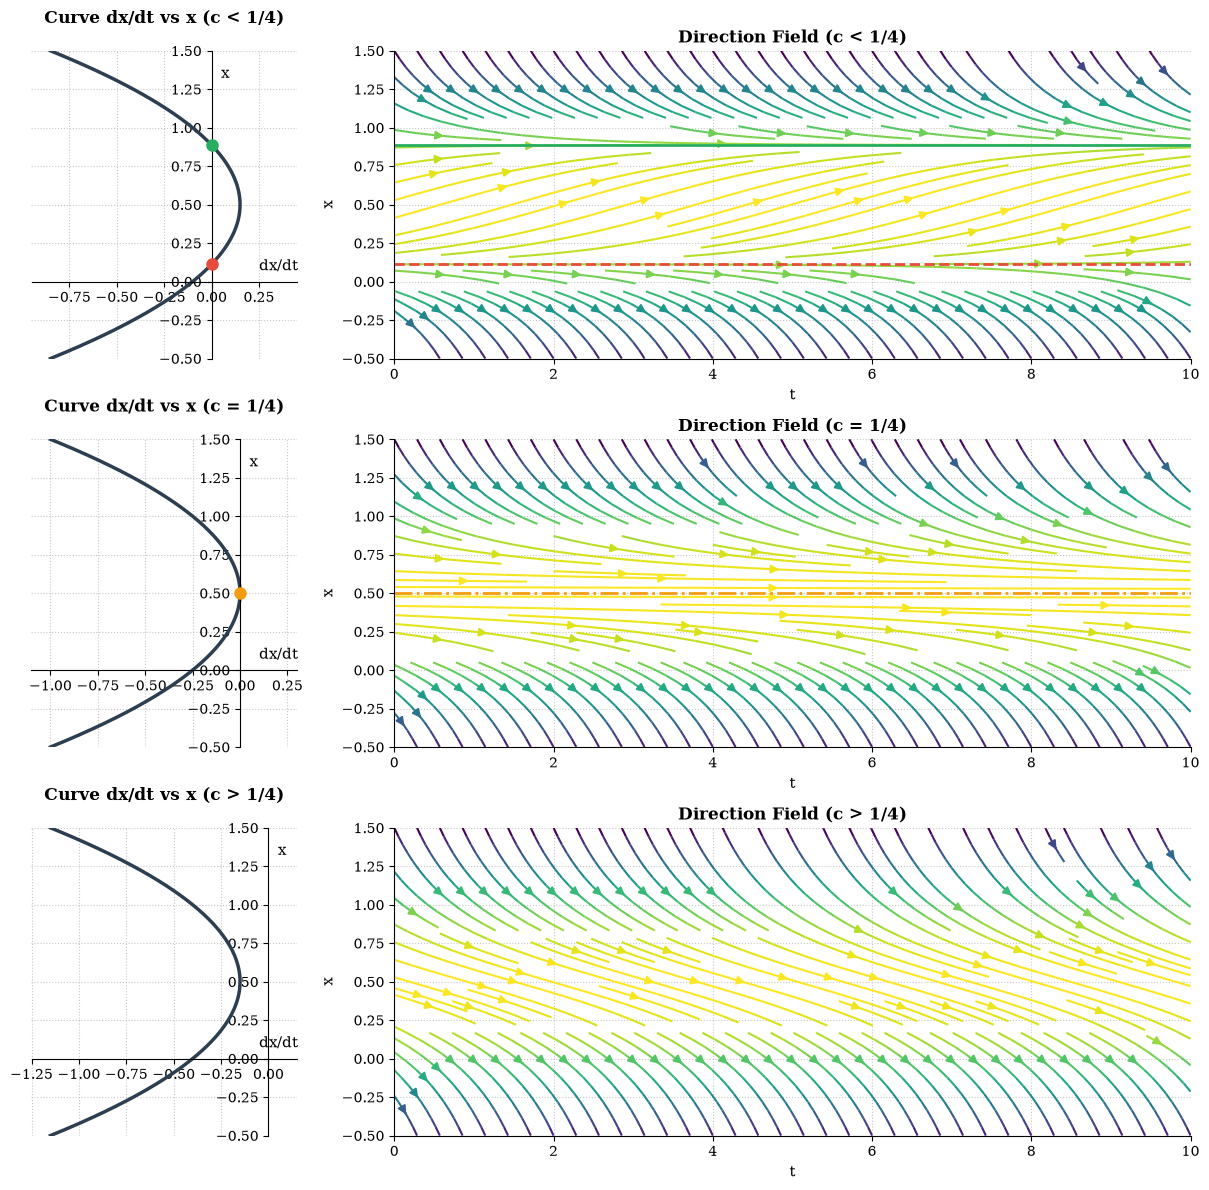

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def dxdt(x, c):
    return -x**2 + x - c

# Values for x and t
x_vals = np.linspace(-0.5, 1.5, 400)
t_vals = np.linspace(0, 10, 400)

# The horizontal axis will be T and the vertical will be X
T, X = np.meshgrid(t_vals, x_vals)

# Three cases for c
c_values = [0.1, 0.25, 0.4] # c < 1/4, c = 1/4, c > 1/4
titles = ["c < 1/4", "c = 1/4", "c > 1/4"]

# Adjust width ratio: 1 for left plot (25%), 3 for right plot (75%)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), gridspec_kw={'width_ratios': [1, 3]})

# Elegant color palette
color_curve = '#2C3E50' # Dark blue
cmap_stream = 'viridis'

for i, c in enumerate(c_values):
    # Left plot: dx/dt on horizontal, x on vertical
    ax_left = axes[i, 0]
    dx = dxdt(x_vals, c)
    ax_left.plot(dx, x_vals, color=color_curve, lw=2.5)
    
    # Enforce identical y-limits to align both plots perfectly
    ax_left.set_ylim(-0.5, 1.5)
    
    # Move left and bottom spines to zero
    ax_left.spines['left'].set_position('zero')
    ax_left.spines['bottom'].set_position('zero')
    ax_left.spines['right'].set_color('none')
    ax_left.spines['top'].set_color('none')
    
    # Remove standard labels that overlap with ticks when spines are centered
    ax_left.set_xlabel("")
    ax_left.set_ylabel("")
    
    # Place labels manually at the ends of the axes to avoid overlap
    dx_max = max(dx)
    dx_min = min(dx)
    ax_left.set_xlim(dx_min - 0.1, dx_max + 0.3)
    ax_left.text(dx_max + 0.1, 0.05, "dx/dt", ha='left', va='bottom', fontsize=11)
    ax_left.text(0.05, 1.40, "x", ha='left', va='top', fontsize=11)
    
    ax_left.set_title(f"Curve dx/dt vs x ({titles[i]})", loc='center', fontsize=12, fontweight='bold', pad=20)
    
    # Elegant grid
    ax_left.grid(True, linestyle=':', alpha=0.7)
    
    # Right plot: Streamplot (Phase and direction field)
    ax_right = axes[i, 1]
    
    # Enforce identical y-limits to align both plots perfectly
    ax_right.set_ylim(-0.5, 1.5)
    
    U = np.ones_like(T) # dt/dt = 1
    V = dxdt(X, c) # dx/dt
    
    speed = np.sqrt(U**2 + V**2)
    
    # Streamplot with colormap based on V (velocity)
    ax_right.streamplot(t_vals, x_vals, U, V, color=V, cmap=cmap_stream, density=1.2, linewidth=1.5, arrowsize=1.2)
    
    # Equilibrium points
    if c < 0.25:
        eq1 = (1 - np.sqrt(1 - 4*c)) / 2
        eq2 = (1 + np.sqrt(1 - 4*c)) / 2
        ax_right.axhline(eq1, color='#E74C3C', lw=2, ls='--') # Red for unstable
        ax_right.axhline(eq2, color='#27AE60', lw=2, ls='-') # Green for stable
        ax_left.plot(0, eq1, 'o', color='#E74C3C', markersize=8, zorder=5) 
        ax_left.plot(0, eq2, 'o', color='#27AE60', markersize=8, zorder=5) 
    elif c == 0.25:
        eq = 0.5
        ax_right.axhline(eq, color='#F39C12', lw=2, ls='-.') # Orange for semi-stable
        ax_left.plot(0, eq, 'o', color='#F39C12', markersize=8, zorder=5) 
        
    ax_right.set_xlabel("t", fontsize=11)
    ax_right.set_ylabel("x", fontsize=11)
    ax_right.set_title(f"Direction Field ({titles[i]})", loc='center', fontsize=12, fontweight='bold')
    
    # Elegant grid
    ax_right.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()